In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# Resolve the repository root independently of
# the notebook's current working directory.
for candidate in (
    Path.cwd(),
    *Path.cwd().parents,
):
    if (
        candidate
        / "pyproject.toml"
    ).is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the repository root."
    )


RUNS_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
)

BRUCKER_GT_RLE_PATH = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "COCO_mask"
    / "brucker_dataset"
    / "test"
    / "annotations_rle.json"
)

BATCH1_SEEDS = [
    0,
    1,
    2,
    42,
    123,
]

EXPECTED_IMAGE_COUNT = 8
EXPECTED_THRESHOLDS = np.arange(
    0.1,
    1.01,
    0.1,
).round(1)


print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Runs root:",
    RUNS_ROOT,
)

print(
    "GT RLE exists:",
    BRUCKER_GT_RLE_PATH.is_file(),
)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Runs root: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs
GT RLE exists: True


### load evaluations

In [2]:
def find_object_metrics_table(
    evaluation_directory,
):
    preferred_path = (
        evaluation_directory
        / "object_metrics_per_image_threshold.csv"
    )

    if preferred_path.is_file():
        return preferred_path

    csv_paths = sorted(
        evaluation_directory.glob(
            "*.csv"
        )
    )

    suitable_paths = []

    required_columns = {
        "matching_metric",
        "threshold",
        "precision",
        "recall",
        "f1_score",
    }

    for csv_path in csv_paths:
        columns = set(
            pd.read_csv(
                csv_path,
                nrows=0,
            ).columns
        )

        if required_columns.issubset(
            columns
        ):
            suitable_paths.append(
                csv_path
            )

    if len(suitable_paths) != 1:
        available_names = [
            path.name
            for path in csv_paths
        ]

        raise RuntimeError(
            "Expected exactly one suitable object "
            "metrics table in "
            f"{evaluation_directory}; found "
            f"{len(suitable_paths)}. Available CSVs: "
            f"{available_names}"
        )

    return suitable_paths[0]


seed_metric_tables = {}
evaluation_file_rows = []


for seed in BATCH1_SEEDS:
    run_name = (
        f"batch1_seed_{seed}_"
        "brucker_test_no_smoothing"
    )

    evaluation_directory = (
        RUNS_ROOT
        / run_name
        / "eval"
        / "irregular_object_eval"
    )

    if not evaluation_directory.is_dir():
        raise FileNotFoundError(
            "Missing evaluation directory for "
            f"seed {seed}: "
            f"{evaluation_directory}"
        )

    metrics_path = (
        find_object_metrics_table(
            evaluation_directory
        )
    )

    seed_df = pd.read_csv(
        metrics_path
    )

    seed_df.insert(
        0,
        "seed",
        seed,
    )

    seed_df.insert(
        1,
        "run_name",
        run_name,
    )

    seed_metric_tables[seed] = (
        seed_df
    )

    evaluation_file_rows.append(
        {
            "seed": seed,
            "run_name": run_name,
            "metrics_file": (
                metrics_path.name
            ),
            "rows": len(seed_df),
            "columns": len(
                seed_df.columns
            ),
        }
    )


evaluation_files_df = pd.DataFrame(
    evaluation_file_rows
)

display(
    evaluation_files_df
)

,seed,run_name,metrics_file,rows,columns
0,0,batch1_seed_0_brucker_test_no_smoothing,object_metrics_per_image_threshold.csv,80,21
1,1,batch1_seed_1_brucker_test_no_smoothing,object_metrics_per_image_threshold.csv,80,21
2,2,batch1_seed_2_brucker_test_no_smoothing,object_metrics_per_image_threshold.csv,80,21
3,42,batch1_seed_42_brucker_test_no_smoothing,object_metrics_per_image_threshold.csv,80,21
4,123,batch1_seed_123_brucker_test_no_smoothing,object_metrics_per_image_threshold.csv,80,21


### combine and validate the loaded results

In [3]:
brucker_object_metrics_df = (
    pd.concat(
        seed_metric_tables.values(),
        ignore_index=True,
    )
)


required_columns = {
    "seed",
    "run_name",
    "matching_metric",
    "threshold",
    "precision",
    "recall",
    "f1_score",
}

missing_columns = (
    required_columns
    - set(
        brucker_object_metrics_df.columns
    )
)

if missing_columns:
    raise RuntimeError(
        "The combined table is missing required "
        f"columns: {sorted(missing_columns)}"
    )


brucker_object_metrics_df[
    "threshold"
] = pd.to_numeric(
    brucker_object_metrics_df[
        "threshold"
    ],
    errors="raise",
)


loaded_thresholds = np.sort(
    brucker_object_metrics_df[
        "threshold"
    ]
    .round(1)
    .unique()
)


if not np.array_equal(
    loaded_thresholds,
    EXPECTED_THRESHOLDS,
):
    raise RuntimeError(
        "Unexpected threshold values. Found: "
        f"{loaded_thresholds.tolist()}"
    )


validation_rows = []


for seed, seed_df in (
    brucker_object_metrics_df.groupby(
        "seed"
    )
):
    matching_metrics = sorted(
        seed_df[
            "matching_metric"
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    thresholds = np.sort(
        seed_df[
            "threshold"
        ]
        .round(1)
        .unique()
    )

    filename_column = next(
        (
            column
            for column in (
                "filename",
                "file_name",
                "image_filename",
                "image_name",
            )
            if column in seed_df.columns
        ),
        None,
    )

    image_count = (
        seed_df[
            filename_column
        ].nunique()
        if filename_column is not None
        else np.nan
    )

    expected_rows = (
        EXPECTED_IMAGE_COUNT
        * len(EXPECTED_THRESHOLDS)
    )

    validation_rows.append(
        {
            "seed": int(seed),
            "rows": len(seed_df),
            "expected rows": expected_rows,
            "image column": filename_column,
            "unique images": image_count,
            "thresholds": len(thresholds),
            "matching metrics": (
                ", ".join(
                    matching_metrics
                )
            ),
            "status": (
                "PASS"
                if (
                    len(seed_df)
                    == expected_rows
                    and len(thresholds)
                    == len(
                        EXPECTED_THRESHOLDS
                    )
                    and matching_metrics
                    == ["cldice"]
                    and (
                        filename_column is None
                        or image_count
                        == EXPECTED_IMAGE_COUNT
                    )
                )
                else "CHECK"
            ),
        }
    )


evaluation_validation_df = (
    pd.DataFrame(
        validation_rows
    )
)


display(
    evaluation_validation_df
)


if not evaluation_validation_df[
    "status"
].eq("PASS").all():
    raise RuntimeError(
        "At least one seed evaluation did not "
        "pass validation. Inspect the table above."
    )


print(
    "Combined rows:",
    len(
        brucker_object_metrics_df
    ),
)

print(
    "Seeds:",
    sorted(
        brucker_object_metrics_df[
            "seed"
        ].unique().tolist()
    ),
)

print(
    "Columns:",
)

for column in (
    brucker_object_metrics_df.columns
):
    print(
        " -",
        column,
    )

,seed,rows,expected rows,image column,unique images,thresholds,matching metrics,status
0,0,80,80,filename,8,10,cldice,PASS
1,1,80,80,filename,8,10,cldice,PASS
2,2,80,80,filename,8,10,cldice,PASS
3,42,80,80,filename,8,10,cldice,PASS
4,123,80,80,filename,8,10,cldice,PASS


Combined rows: 400
Seeds: [0, 1, 2, 42, 123]
Columns:
 - seed
 - run_name
 - filename
 - matching_metric
 - threshold
 - num_gt_objects
 - num_pred_objects
 - true_positives
 - false_positives
 - false_negatives
 - precision
 - recall
 - f1_score
 - dsb_precision
 - matched_feature_pair_count
 - irregular_matched_prediction_count
 - mean_absolute_length_error_um
 - mean_absolute_relative_length_error
 - mean_absolute_orientation_error_deg
 - num_pred_objects_before_endpoint_filter
 - num_pred_objects_rejected_by_endpoint_filter


### calculate model-level macro F1 scores

In [4]:
from scipy.stats import t as student_t


# First calculate the macro mean across the eight
# Brucker images separately for every seed and threshold.
seed_threshold_metrics_df = (
    brucker_object_metrics_df
    .groupby(
        [
            "seed",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        macro_precision=(
            "precision",
            "mean",
        ),
        macro_recall=(
            "recall",
            "mean",
        ),
        macro_f1=(
            "f1_score",
            "mean",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
    .sort_values(
        [
            "seed",
            "threshold",
        ]
    )
    .reset_index(drop=True)
)


if len(seed_threshold_metrics_df) != (
    len(BATCH1_SEEDS)
    * len(EXPECTED_THRESHOLDS)
):
    raise RuntimeError(
        "Expected one macro-metric row for each "
        "seed and threshold."
    )


if not seed_threshold_metrics_df[
    "image_count"
].eq(EXPECTED_IMAGE_COUNT).all():
    raise RuntimeError(
        "At least one seed-threshold combination "
        "does not contain all eight images."
    )


display(
    seed_threshold_metrics_df
)

,seed,threshold,macro_precision,macro_recall,macro_f1,image_count
0,0,0.1,0.719752,0.934134,0.812602,8
1,0,0.2,0.712076,0.924305,0.803987,8
2,0,0.3,0.697898,0.906016,0.788021,8
3,0,0.4,0.667326,0.866308,0.753495,8
4,0,0.5,0.625617,0.812649,0.706587,8
5,0,0.6,0.548150,0.712762,0.619381,8
6,0,0.7,0.442665,0.575929,0.500311,8
7,0,0.8,0.320355,0.417214,0.362237,8
8,0,0.9,0.161816,0.210595,0.182915,8
9,0,1.0,0.018046,0.023313,0.020331,8


### obtain the two F1 measurements for every model

In [5]:
seed_mean_threshold_f1_df = (
    seed_threshold_metrics_df
    .groupby(
        "seed",
        as_index=False,
    )
    .agg(
        f1_cldice=(
            "macro_f1",
            "mean",
        ),
        threshold_count=(
            "threshold",
            "nunique",
        ),
    )
)


# F1 at the fixed clDice matching threshold t = 0.5.
seed_f1_at_0p5_df = (
    seed_threshold_metrics_df.loc[
        np.isclose(
            seed_threshold_metrics_df[
                "threshold"
            ],
            0.5,
        ),
        [
            "seed",
            "macro_f1",
        ],
    ]
    .rename(
        columns={
            "macro_f1": (
                "f1_cldice_at_0p5"
            ),
        }
    )
)


seed_f1_summary_df = (
    seed_mean_threshold_f1_df
    .merge(
        seed_f1_at_0p5_df,
        on="seed",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("seed")
    .reset_index(drop=True)
)


if len(seed_f1_summary_df) != len(
    BATCH1_SEEDS
):
    raise RuntimeError(
        "Expected one result row for each of "
        "the five trained models."
    )


if not seed_f1_summary_df[
    "threshold_count"
].eq(
    len(EXPECTED_THRESHOLDS)
).all():
    raise RuntimeError(
        "The across-threshold F1 was not calculated "
        "from all ten thresholds."
    )


display(
    seed_f1_summary_df[
        [
            "seed",
            "f1_cldice",
            "f1_cldice_at_0p5",
        ]
    ].style.format(
        {
            "f1_cldice": "{:.4f}",
            "f1_cldice_at_0p5": "{:.4f}",
        }
    )
)

,seed,f1_cldice,f1_cldice_at_0p5
0,0,0.5550,0.7066
1,1,0.5024,0.6418
2,2,0.5405,0.6863
3,42,0.5269,0.6847
4,123,0.5443,0.6895


### summarize performance across the five models

In [6]:
# %%
def summarize_across_models(
    values,
    *,
    metric_label,
):
    values = pd.to_numeric(
        values,
        errors="coerce",
    ).dropna()

    model_count = len(values)

    if model_count != len(
        BATCH1_SEEDS
    ):
        raise RuntimeError(
            f"{metric_label} contains "
            f"{model_count} valid model-level "
            "values; expected "
            f"{len(BATCH1_SEEDS)}."
        )

    mean = float(
        values.mean()
    )

    standard_deviation = float(
        values.std(ddof=1)
    )

    standard_error = (
        standard_deviation
        / np.sqrt(model_count)
    )

    t_critical = float(
        student_t.ppf(
            0.975,
            df=model_count - 1,
        )
    )

    ci_half_width = (
        t_critical
        * standard_error
    )

    ci_lower = mean - ci_half_width
    ci_upper = mean + ci_half_width

    return {
        "Metric": metric_label,
        "Mean": mean,
        "Standard deviation": (
            standard_deviation
        ),
        "Standard error": (
            standard_error
        ),
        "95% CI lower": ci_lower,
        "95% CI upper": ci_upper,
        "95% CI half-width": (
            ci_half_width
        ),
        "Number of models": model_count,
        "Images per model": (
            EXPECTED_IMAGE_COUNT
        ),
    }


def find_pixel_metrics_table(
    evaluation_directory,
):
    preferred_path = (
        evaluation_directory
        / "pixel_metrics_per_image.csv"
    )

    if preferred_path.is_file():
        return preferred_path

    suitable_paths = []

    for csv_path in sorted(
        evaluation_directory.glob(
            "*.csv"
        )
    ):
        columns = set(
            pd.read_csv(
                csv_path,
                nrows=0,
            ).columns
        )

        if "pixel_cldice" in columns:
            suitable_paths.append(
                csv_path
            )

    if len(suitable_paths) != 1:
        available_names = [
            path.name
            for path in sorted(
                evaluation_directory.glob(
                    "*.csv"
                )
            )
        ]

        raise RuntimeError(
            "Expected exactly one pixel-metrics "
            f"CSV in {evaluation_directory}; "
            f"found {len(suitable_paths)}. "
            f"Available CSVs: {available_names}"
        )

    return suitable_paths[0]


pixel_metric_tables = {}
pixel_evaluation_file_rows = []


for seed in BATCH1_SEEDS:
    run_name = (
        f"batch1_seed_{seed}_"
        "brucker_test_no_smoothing"
    )

    evaluation_directory = (
        RUNS_ROOT
        / run_name
        / "eval"
        / "irregular_object_eval"
    )

    pixel_metrics_path = (
        find_pixel_metrics_table(
            evaluation_directory
        )
    )

    pixel_df = pd.read_csv(
        pixel_metrics_path
    )

    filename_column = next(
        (
            column
            for column in (
                "filename",
                "file_name",
                "image_filename",
                "image_name",
            )
            if column in pixel_df.columns
        ),
        None,
    )

    if filename_column is None:
        raise RuntimeError(
            "Could not identify the filename "
            f"column in {pixel_metrics_path}."
        )

    required_pixel_columns = {
        filename_column,
        "pixel_cldice",
    }

    missing_pixel_columns = (
        required_pixel_columns
        - set(pixel_df.columns)
    )

    if missing_pixel_columns:
        raise RuntimeError(
            f"Seed {seed} pixel table is missing "
            f"columns: "
            f"{sorted(missing_pixel_columns)}"
        )

    if len(pixel_df) != EXPECTED_IMAGE_COUNT:
        raise RuntimeError(
            f"Seed {seed} contains "
            f"{len(pixel_df)} pixel-metric rows; "
            f"expected {EXPECTED_IMAGE_COUNT}."
        )

    if pixel_df[
        filename_column
    ].nunique() != EXPECTED_IMAGE_COUNT:
        raise RuntimeError(
            f"Seed {seed} does not contain eight "
            "unique image-level pixel results."
        )

    pixel_df.insert(
        0,
        "seed",
        seed,
    )

    pixel_df.insert(
        1,
        "run_name",
        run_name,
    )

    pixel_metric_tables[seed] = (
        pixel_df
    )

    pixel_evaluation_file_rows.append(
        {
            "seed": seed,
            "metrics_file": (
                pixel_metrics_path.name
            ),
            "rows": len(pixel_df),
            "mean_pixel_cldice": float(
                pd.to_numeric(
                    pixel_df[
                        "pixel_cldice"
                    ],
                    errors="raise",
                ).mean()
            ),
        }
    )


brucker_pixel_metrics_df = (
    pd.concat(
        pixel_metric_tables.values(),
        ignore_index=True,
    )
)


# Each value below is the macro mean pixel clDice
# across the same eight Brucker images for one model.
seed_pixel_cldice_df = (
    brucker_pixel_metrics_df
    .groupby(
        "seed",
        as_index=False,
    )
    .agg(
        pixel_cldice=(
            "pixel_cldice",
            "mean",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
    .sort_values("seed")
    .reset_index(drop=True)
)


if len(seed_pixel_cldice_df) != len(
    BATCH1_SEEDS
):
    raise RuntimeError(
        "Expected one pixel clDice macro mean "
        "for each of the five models."
    )


if not seed_pixel_cldice_df[
    "image_count"
].eq(EXPECTED_IMAGE_COUNT).all():
    raise RuntimeError(
        "At least one model-level pixel clDice "
        "mean was not calculated from eight images."
    )


display(
    seed_pixel_cldice_df.style.format(
        {
            "pixel_cldice": "{:.4f}",
        }
    )
)


brucker_performance_summary_df = (
    pd.DataFrame(
        [
            summarize_across_models(
                seed_f1_summary_df[
                    "f1_cldice"
                ],
                metric_label=(
                    "Object F1 clDice "
                    "(mean across thresholds)"
                ),
            ),
            summarize_across_models(
                seed_f1_summary_df[
                    "f1_cldice_at_0p5"
                ],
                metric_label=(
                    "Object F1 clDice at t = 0.5"
                ),
            ),
            summarize_across_models(
                seed_pixel_cldice_df[
                    "pixel_cldice"
                ],
                metric_label=(
                    "Pixel-level clDice"
                ),
            ),
        ]
    )
)


display(
    brucker_performance_summary_df
)

,seed,pixel_cldice,image_count
0,0,0.8465,8
1,1,0.8292,8
2,2,0.8427,8
3,42,0.8326,8
4,123,0.8422,8


,Metric,Mean,Standard deviation,Standard error,95% CI lower,95% CI upper,95% CI half-width,Number of models,Images per model
0,Object F1 clDice (mean across thresholds),0.533818,0.020244,0.009053,0.508682,0.558954,0.025136,5,8
1,Object F1 clDice at t = 0.5,0.681768,0.023999,0.010733,0.651969,0.711566,0.029798,5,8
2,Pixel-level clDice,0.838637,0.007386,0.003303,0.829465,0.847808,0.009172,5,8


### display the table

In [7]:
brucker_manuscript_table_df = (
    brucker_performance_summary_df[
        [
            "Metric",
            "Mean",
            "Standard deviation",
            "95% CI lower",
            "95% CI upper",
            "Number of models",
            "Images per model",
        ]
    ]
    .copy()
)


brucker_manuscript_table_df[
    "Mean ± SD"
] = (
    brucker_manuscript_table_df.apply(
        lambda row: (
            f"{row['Mean']:.3f} ± "
            f"{row['Standard deviation']:.3f}"
        ),
        axis=1,
    )
)


brucker_manuscript_table_df[
    "95% CI"
] = (
    brucker_manuscript_table_df.apply(
        lambda row: (
            f"[{row['95% CI lower']:.3f}, "
            f"{row['95% CI upper']:.3f}]"
        ),
        axis=1,
    )
)


brucker_word_table_df = (
    brucker_manuscript_table_df[
        [
            "Metric",
            "Mean ± SD",
            "95% CI",
            "Number of models",
            "Images per model",
        ]
    ]
    .rename(
        columns={
            "Number of models": "Models (n)",
            "Images per model": (
                "External test images"
            ),
        }
    )
)


display(
    brucker_word_table_df
)

,Metric,Mean ± SD,95% CI,Models (n),External test images
0,Object F1 clDice (mean across thresholds),0.534 ± 0.020,"[0.509, 0.559]",5,8
1,Object F1 clDice at t = 0.5,0.682 ± 0.024,"[0.652, 0.712]",5,8
2,Pixel-level clDice,0.839 ± 0.007,"[0.829, 0.848]",5,8


### F1 across clDice thresholds for each trained model

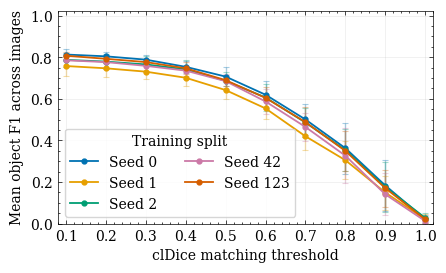

In [10]:
import matplotlib.pyplot as plt
import scienceplots


FIGURE_SIZE = (
    4.5,
    2.8,
)

SEED_COLORS = {
    0: "#0072B2",
    1: "#E69F00",
    2: "#009E73",
    42: "#CC79A7",
    123: "#D55E00",
}


# Calculate the mean and sample standard deviation
# across the eight images for every seed and threshold.
seed_threshold_plot_df = (
    brucker_object_metrics_df
    .groupby(
        [
            "seed",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        mean_f1=(
            "f1_score",
            "mean",
        ),
        std_f1=(
            "f1_score",
            "std",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
    .sort_values(
        [
            "seed",
            "threshold",
        ]
    )
    .reset_index(drop=True)
)


if not seed_threshold_plot_df[
    "image_count"
].eq(EXPECTED_IMAGE_COUNT).all():
    raise RuntimeError(
        "At least one seed-threshold combination "
        "does not contain all eight images."
    )


with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    figure, axis = plt.subplots(
        figsize=FIGURE_SIZE,
    )

    for seed in BATCH1_SEEDS:
        seed_curve_df = (
            seed_threshold_plot_df.loc[
                seed_threshold_plot_df[
                    "seed"
                ].eq(seed)
            ]
            .sort_values(
                "threshold"
            )
        )

        if len(seed_curve_df) != len(
            EXPECTED_THRESHOLDS
        ):
            raise RuntimeError(
                f"Seed {seed} does not contain "
                "all expected thresholds."
            )

        thresholds = (
            seed_curve_df[
                "threshold"
            ].to_numpy(dtype=float)
        )

        mean_f1 = (
            seed_curve_df[
                "mean_f1"
            ].to_numpy(dtype=float)
        )

        std_f1 = (
            seed_curve_df[
                "std_f1"
            ].to_numpy(dtype=float)
        )

        color = SEED_COLORS[
            seed
        ]

        # Transparent vertical ±1 SD intervals.
        axis.errorbar(
            thresholds,
            mean_f1,
            yerr=std_f1,
            fmt="none",
            ecolor=color,
            elinewidth=1.0,
            capsize=2.0,
            capthick=0.8,
            alpha=0.35,
            zorder=1,
        )

        # Mean F1 curve.
        axis.plot(
            thresholds,
            mean_f1,
            color=color,
            marker="o",
            markersize=3.5,
            linewidth=1.3,
            label=f"Seed {seed}",
            zorder=2,
        )


    # axis.set_title(
    #     "NanoVision performance on the Brucker data"
    # )

    axis.set_xlabel(
        "clDice matching threshold"
    )

    axis.set_ylabel(
        "Mean object F1 across images"
    )

    axis.set_xticks(
        EXPECTED_THRESHOLDS
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    axis.set_xlim(
        0.08,
        1.02,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )

    axis.grid(
        alpha=0.25,
    )

    axis.legend(
        title="Training split",
        frameon=True,
        ncol=2,
    )

    figure.tight_layout()

    figure.savefig(
        "bruker_external_validation_object_f1.svg",
        format="svg",
        bbox_inches="tight",
        pad_inches=0.02,
    )

    figure.savefig(
        "bruker_external_validation_object_f1.png",
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02,
    )


plt.show()